# 2017 Periodontal Staging - Dataset And Results Review

Mentor-facing notebook for the revived BRAR panoramic-radiograph classifier.

This notebook visualizes:
- the professor-labeled 2017 staging subset,
- how the train/validation/test splits are distributed,
- patient metadata patterns available in BRAR,
- example panoramic images by stage,
- training dynamics from the completed run,
- test-set performance, confusion matrix, and prediction errors.

Ground truth here is `2017_classification.csv`; the old BRAR `Level` is shown only as historical metadata.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

STAGE_ORDER = [1, 2, 3, 4]
STAGE_NAMES = {1: "Stage I", 2: "Stage II", 3: "Stage III", 4: "Stage IV"}
STAGE_PALETTE = {
    "Stage I": "#4C78A8",
    "Stage II": "#59A14F",
    "Stage III": "#F28E2B",
    "Stage IV": "#E15759",
}

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "scripts").exists():
            return candidate
    raise RuntimeError("Could not find brar_classification project root.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_ROOT = (PROJECT_ROOT / ".." / "brar_anotation_dataset" / "brar").resolve()
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
RUN_DIR = PROJECT_ROOT / "runs" / "2017_classification" / "efficientnet_b4"
EVAL_DIR = RUN_DIR / "eval_test"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_ROOT}")
print(f"Run dir:      {RUN_DIR}")

Project root: D:\master-thesis\brar_classification
Data root:    D:\master-thesis\brar_anotation_dataset\brar
Run dir:      D:\master-thesis\brar_classification\runs\2017_classification\efficientnet_b4


In [3]:
audit = json.loads((SPLITS_DIR / "audit_summary.json").read_text())
splits = {name: pd.read_csv(SPLITS_DIR / f"{name}.csv") for name in ["train", "val", "test"]}
data = pd.concat(splits.values(), ignore_index=True)
history = pd.read_json(RUN_DIR / "history.json")
metrics = json.loads((EVAL_DIR / "metrics.json").read_text())
preds = pd.read_csv(EVAL_DIR / "predictions.csv")
preds = preds.merge(data[["image_id", "image_path"]], on="image_id", how="left")

data["stage_label"] = data["stage_2017"].map(STAGE_NAMES)
preds["true_stage_label"] = preds["true_stage"].map(STAGE_NAMES)
preds["pred_stage_label"] = preds["pred_stage"].map(STAGE_NAMES)

display(Markdown(
    f"Loaded **{len(data)} professor-labeled images** and **{len(preds)} test predictions**."
))
display(data.head())

Loaded **252 professor-labeled images** and **38 test predictions**.

,image_id,File name,image_path,stage_2017,label,stage_name,brar_level,old_level_dir,Age,Gender,Bone resorption,Bone resorption Age,Number of missing teeth,Implant,Residual root,Functional tooth logarithm,label_source,split,stage_label
0,3,patient_image_000003_2b2e7506.jpg,level_3/patient_image_000003_2b2e7506.jpg,1,0,Stage I,3,level_3,19,1,0.270834,1.425444,0,0,0,14,professor_2017,train,Stage I
1,7,patient_image_000007_833861b5.jpg,level_3/patient_image_000007_833861b5.jpg,1,0,Stage I,3,level_3,19,1,0.217949,1.147099,0,0,0,14,professor_2017,train,Stage I
2,19,patient_image_000019_23caeef3.jpg,level_3/patient_image_000019_23caeef3.jpg,2,1,Stage II,3,level_3,21,1,0.248279,1.182283,0,0,0,14,professor_2017,train,Stage II
3,21,patient_image_000021_1f767ab9.jpg,level_3/patient_image_000021_1f767ab9.jpg,1,0,Stage I,3,level_3,21,1,0.218044,1.038304,0,0,1,13,professor_2017,train,Stage I
4,44,patient_image_000044_069a1491.jpg,level_3/patient_image_000044_069a1491.jpg,2,1,Stage II,3,level_3,22,1,0.290598,1.320901,0,0,0,14,professor_2017,train,Stage II


## Headline Summary

The classifier is not just guessing Stage III: it reaches useful performance on Stage III and Stage IV, while Stage I remains the expected weak point because there are only 10 labeled Stage I images total.

In [4]:
summary = pd.DataFrame({
    "Value": {
        "Professor-labeled images": audit["labels_loaded"],
        "Images without 2017 label": audit["images_without_2017_label"],
        "Test accuracy": metrics["accuracy"],
        "Test balanced accuracy": metrics["balanced_accuracy"],
        "Test macro F1": metrics["f1_macro"],
        "Test weighted F1": metrics["f1_weighted"],
        "Ordinal stage MAE": metrics["ordinal_stage_mae"],
    }
})

display(summary.style.format({"Value": "{:.3f}"}))

stage_counts = data["stage_2017"].value_counts().reindex(STAGE_ORDER).rename(index=STAGE_NAMES)
display(pd.DataFrame({"count": stage_counts, "percent": stage_counts / stage_counts.sum() * 100}).style.format({"percent": "{:.1f}%"}))

,Value
Professor-labeled images,252.000
Images without 2017 label,736.000
Test accuracy,0.737
Test balanced accuracy,0.510
Test macro F1,0.528
Test weighted F1,0.714
Ordinal stage MAE,0.263


,count,percent
stage_2017,,
Stage I,10,4.0%
Stage II,53,21.0%
Stage III,140,55.6%
Stage IV,49,19.4%


## Dataset Audit And Label Distribution

The new 2017 labels cleanly match real image files. The main scientific limitation is class imbalance, especially Stage I.

,Audit item,Count
0,Labels loaded,252
1,Missing labeled images,0
2,Duplicate label ids,0
3,Duplicate image ids,0
4,Images without 2017 label,736


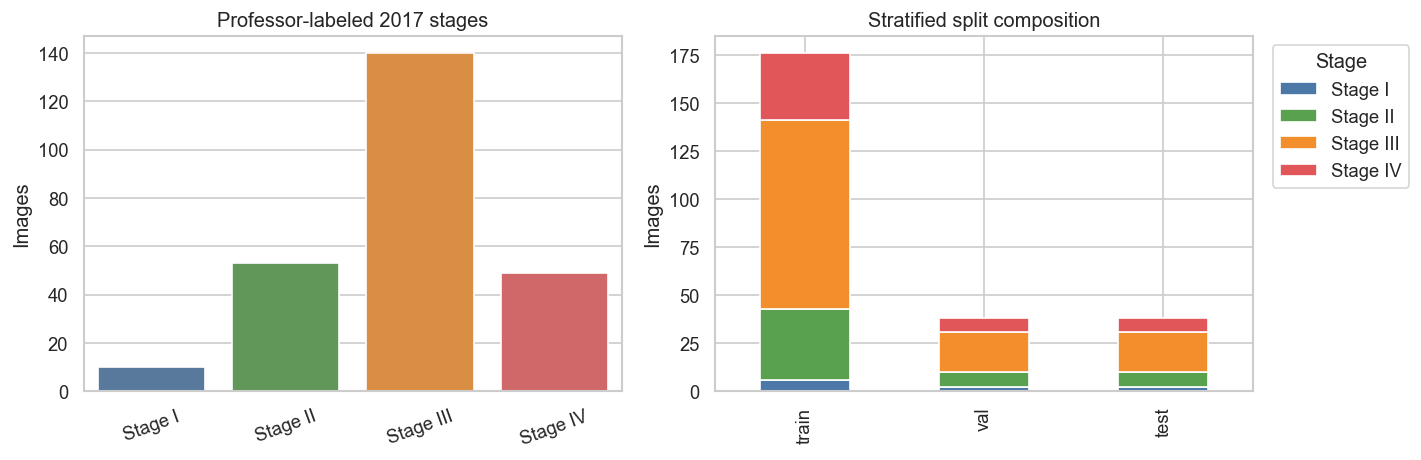

stage_label,Stage I,Stage II,Stage III,Stage IV
split,,,,
train,6,37,98,35
val,2,8,21,7
test,2,8,21,7


In [5]:
audit_table = pd.DataFrame([
    ("Labels loaded", audit["labels_loaded"]),
    ("Missing labeled images", audit["missing_labeled_images"]),
    ("Duplicate label ids", audit["duplicate_label_ids"]),
    ("Duplicate image ids", audit["duplicate_image_ids"]),
    ("Images without 2017 label", audit["images_without_2017_label"]),
], columns=["Audit item", "Count"])
display(audit_table)

split_counts = pd.crosstab(data["split"], data["stage_label"]).reindex(["train", "val", "test"])
split_counts = split_counts[[STAGE_NAMES[i] for i in STAGE_ORDER]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(
    x=stage_counts.index,
    y=stage_counts.values,
    hue=stage_counts.index,
    palette=STAGE_PALETTE,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Professor-labeled 2017 stages")
axes[0].set_xlabel("")
axes[0].set_ylabel("Images")
for tick in axes[0].get_xticklabels():
    tick.set_rotation(20)

split_counts.plot(kind="bar", stacked=True, color=[STAGE_PALETTE[c] for c in split_counts.columns], ax=axes[1])
axes[1].set_title("Stratified split composition")
axes[1].set_xlabel("")
axes[1].set_ylabel("Images")
axes[1].legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(split_counts)

## Metadata Patterns

These plots are descriptive only. They are useful for discussing the cohort, but the current baseline model is image-only.

C:\Users\DT User\AppData\Local\Temp\ipykernel_4340\2389912663.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="stage_label", y="Age", order=[STAGE_NAMES[i] for i in STAGE_ORDER], palette=STAGE_PALETTE, ax=axes[0, 0])
C:\Users\DT User\AppData\Local\Temp\ipykernel_4340\2389912663.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="stage_label", y="Bone resorption Age", order=[STAGE_NAMES[i] for i in STAGE_ORDER], palette=STAGE_PALETTE, ax=axes[1, 0])


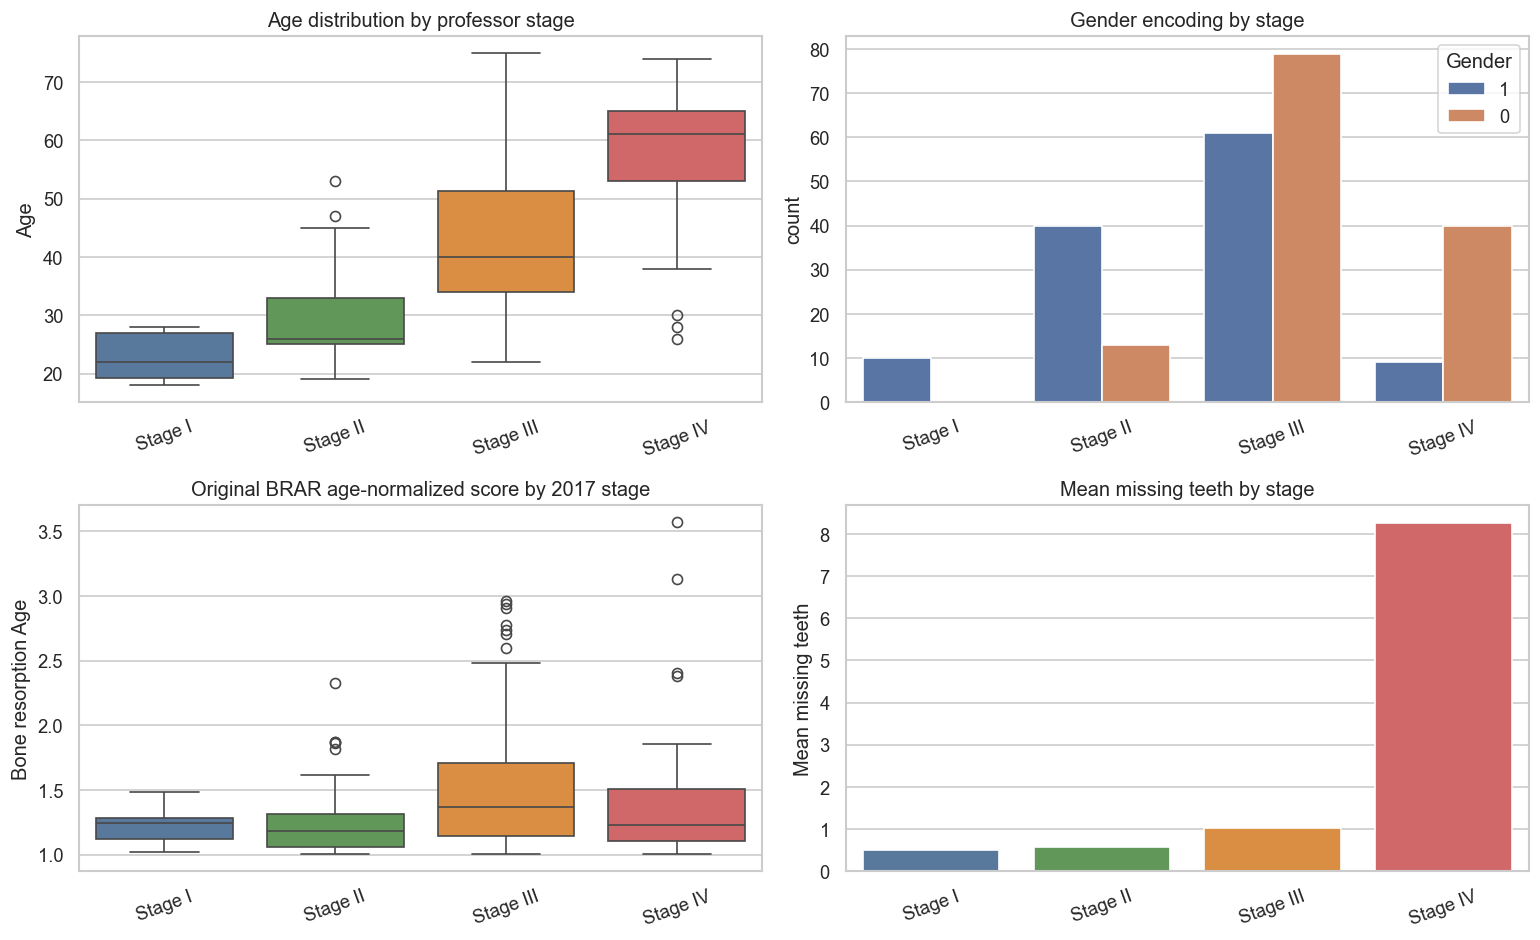

In [6]:
plot_df = data.copy()
plot_df["Gender encoded"] = plot_df["Gender"].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.boxplot(data=plot_df, x="stage_label", y="Age", order=[STAGE_NAMES[i] for i in STAGE_ORDER], palette=STAGE_PALETTE, ax=axes[0, 0])
axes[0, 0].set_title("Age distribution by professor stage")
axes[0, 0].set_xlabel("")

sns.countplot(data=plot_df, x="stage_label", hue="Gender encoded", order=[STAGE_NAMES[i] for i in STAGE_ORDER], ax=axes[0, 1])
axes[0, 1].set_title("Gender encoding by stage")
axes[0, 1].set_xlabel("")
axes[0, 1].legend(title="Gender")

sns.boxplot(data=plot_df, x="stage_label", y="Bone resorption Age", order=[STAGE_NAMES[i] for i in STAGE_ORDER], palette=STAGE_PALETTE, ax=axes[1, 0])
axes[1, 0].set_title("Original BRAR age-normalized score by 2017 stage")
axes[1, 0].set_xlabel("")

missing_summary = plot_df.groupby("stage_label", observed=True)["Number of missing teeth"].mean().reindex([STAGE_NAMES[i] for i in STAGE_ORDER])
sns.barplot(x=missing_summary.index, y=missing_summary.values, hue=missing_summary.index, palette=STAGE_PALETTE, legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Mean missing teeth by stage")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Mean missing teeth")

for ax in axes.flat:
    for tick in ax.get_xticklabels():
        tick.set_rotation(20)

plt.tight_layout()
plt.show()

## Example Radiographs By 2017 Stage

A compact visual sanity check: these are real images from the professor-labeled subset.

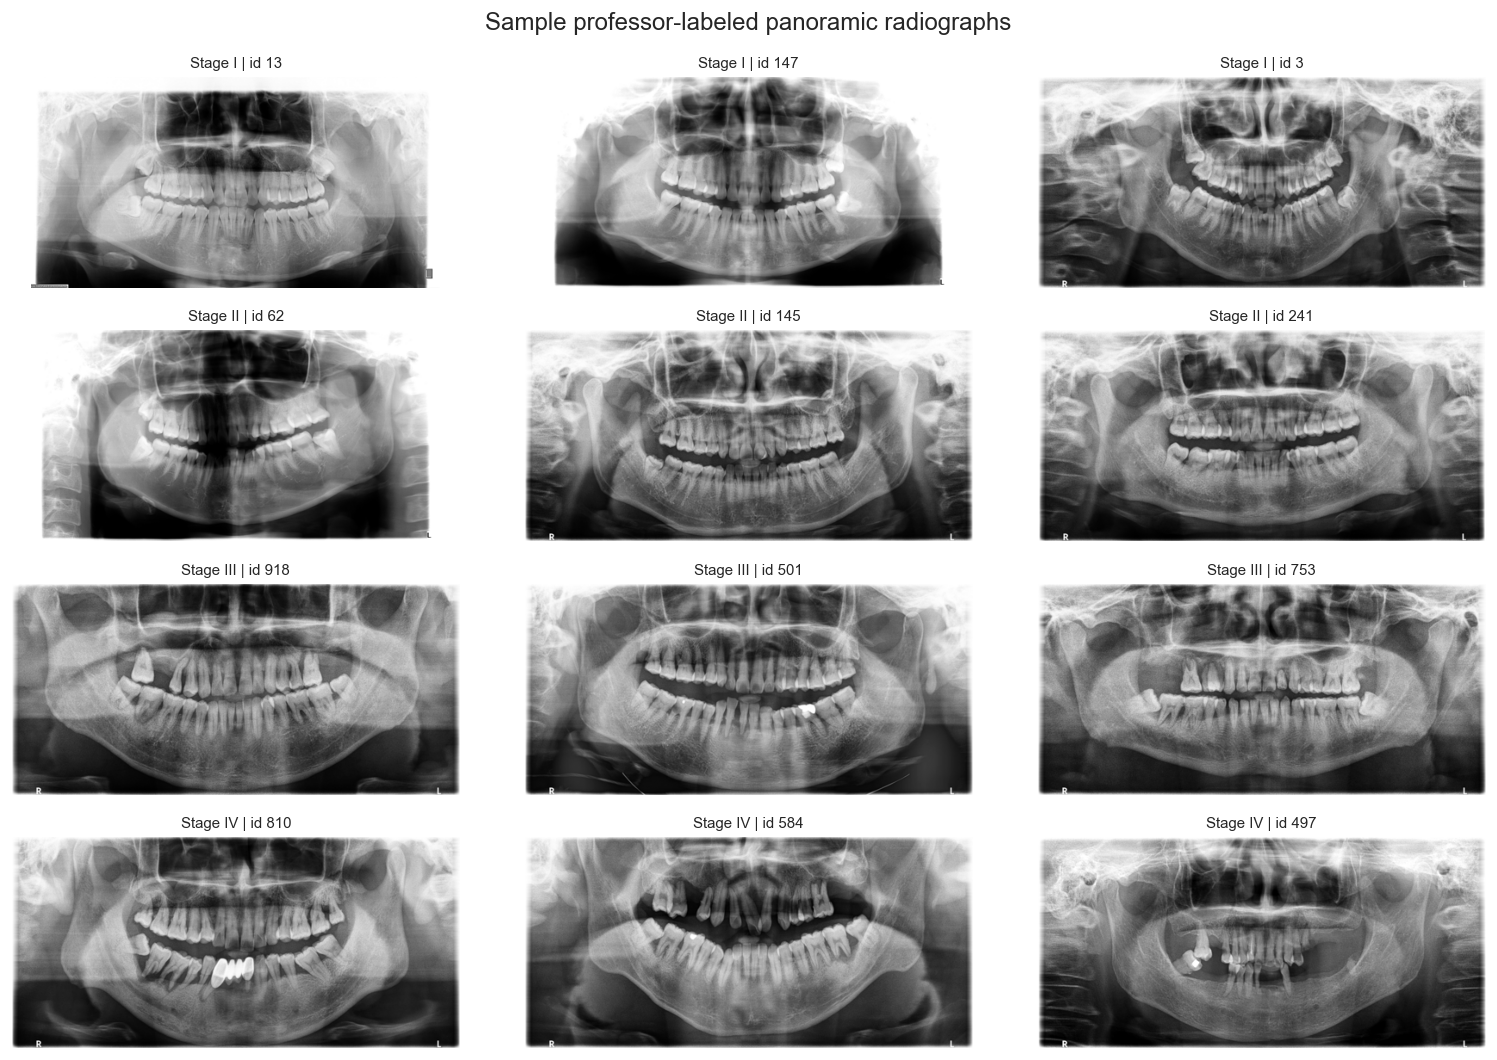

In [7]:
def load_thumbnail(path: Path, max_size=(520, 260)):
    image = Image.open(path).convert("L")
    image.thumbnail(max_size)
    return image

samples_per_stage = 3
sample_rows = []
for stage in STAGE_ORDER:
    stage_rows = data[data["stage_2017"] == stage].sample(
        n=min(samples_per_stage, (data["stage_2017"] == stage).sum()),
        random_state=17 + stage,
    )
    sample_rows.extend(stage_rows.to_dict("records"))

fig, axes = plt.subplots(len(STAGE_ORDER), samples_per_stage, figsize=(13, 9))
for ax in axes.flat:
    ax.axis("off")

for row_idx, stage in enumerate(STAGE_ORDER):
    rows = [r for r in sample_rows if r["stage_2017"] == stage]
    for col_idx, row in enumerate(rows):
        ax = axes[row_idx, col_idx]
        img_path = DATA_ROOT / row["image_path"]
        ax.imshow(load_thumbnail(img_path), cmap="gray")
        ax.set_title(f"{STAGE_NAMES[stage]} | id {int(row['image_id'])}", fontsize=9)
        ax.axis("off")

plt.suptitle("Sample professor-labeled panoramic radiographs", y=0.98)
plt.tight_layout()
plt.show()

## Training Dynamics

The model learns signal quickly, then starts to overfit. The selected checkpoint is the epoch with best validation macro F1.

Best validation checkpoint: **epoch 12**, macro F1 **0.575**, balanced accuracy **0.670**.

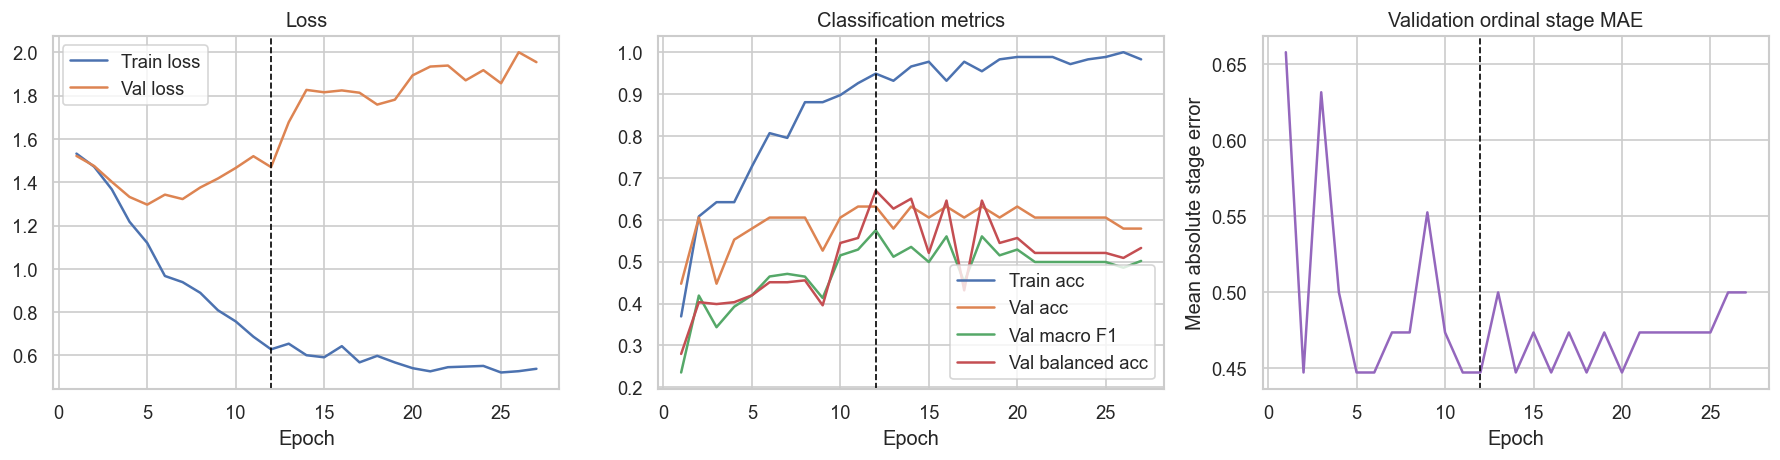

In [8]:
best_idx = history["val_macro_f1"].idxmax()
best_row = history.loc[best_idx]
best_epoch = int(best_row["epoch"])

display(Markdown(
    f"Best validation checkpoint: **epoch {best_epoch}**, "
    f"macro F1 **{best_row['val_macro_f1']:.3f}**, "
    f"balanced accuracy **{best_row['val_balanced_accuracy']:.3f}**."
))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="Train loss")
axes[0].plot(history["epoch"], history["val_loss"], label="Val loss")
axes[0].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_acc"], label="Train acc")
axes[1].plot(history["epoch"], history["val_acc"], label="Val acc")
axes[1].plot(history["epoch"], history["val_macro_f1"], label="Val macro F1")
axes[1].plot(history["epoch"], history["val_balanced_accuracy"], label="Val balanced acc")
axes[1].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Classification metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["epoch"], history["val_ordinal_mae"], color="#9467BD")
axes[2].axvline(best_epoch, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Validation ordinal stage MAE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean absolute stage error")

plt.tight_layout()
plt.show()

## Test Results

The test set has only 38 images, so confidence intervals would be wide. Treat this as a promising baseline, not a final clinical claim.

In [9]:
metric_rows = [
    ("Accuracy", metrics["accuracy"]),
    ("Balanced accuracy", metrics["balanced_accuracy"]),
    ("Macro F1", metrics["f1_macro"]),
    ("Weighted F1", metrics["f1_weighted"]),
    ("Ordinal stage MAE", metrics["ordinal_stage_mae"]),
]
display(pd.DataFrame(metric_rows, columns=["Metric", "Value"]).style.format({"Value": "{:.3f}"}))

report = pd.DataFrame(metrics["classification_report"]).T
display(report.loc[[STAGE_NAMES[i] for i in STAGE_ORDER], ["precision", "recall", "f1-score", "support"]].style.format("{:.3f}"))

,Metric,Value
0,Accuracy,0.737
1,Balanced accuracy,0.510
2,Macro F1,0.528
3,Weighted F1,0.714
4,Ordinal stage MAE,0.263


,precision,recall,f1-score,support
Stage I,0.000,0.000,0.000,2.000
Stage II,0.500,0.375,0.429,8.000
Stage III,0.769,0.952,0.851,21.000
Stage IV,1.000,0.714,0.833,7.000


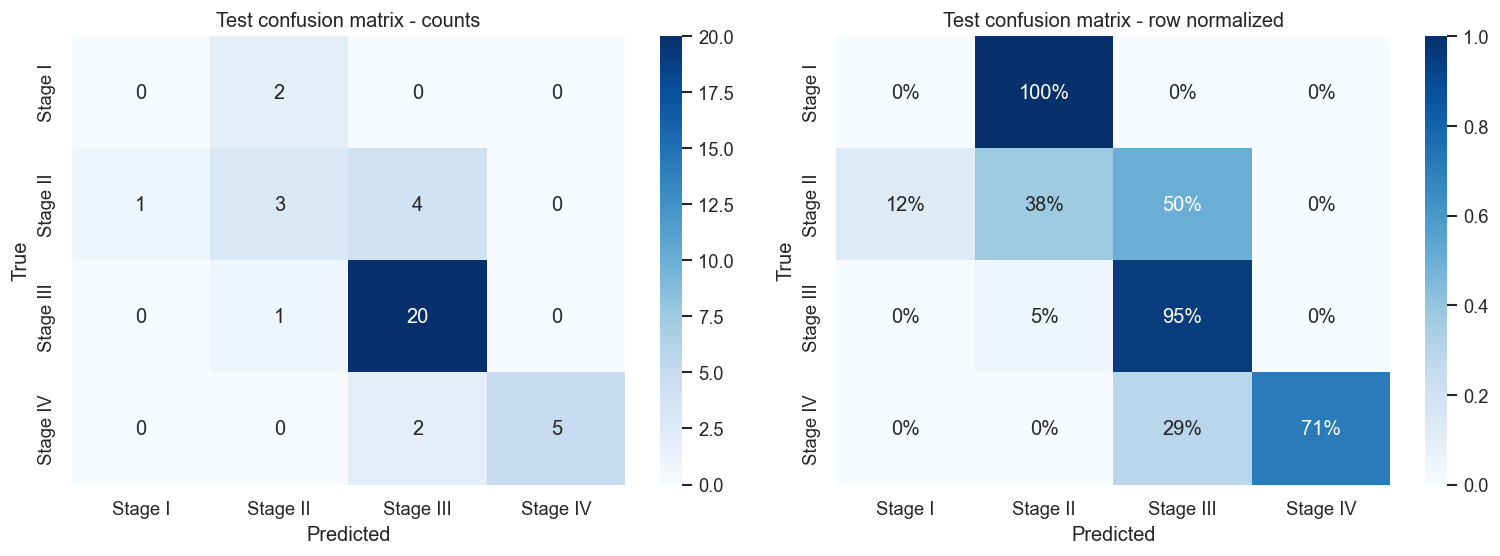

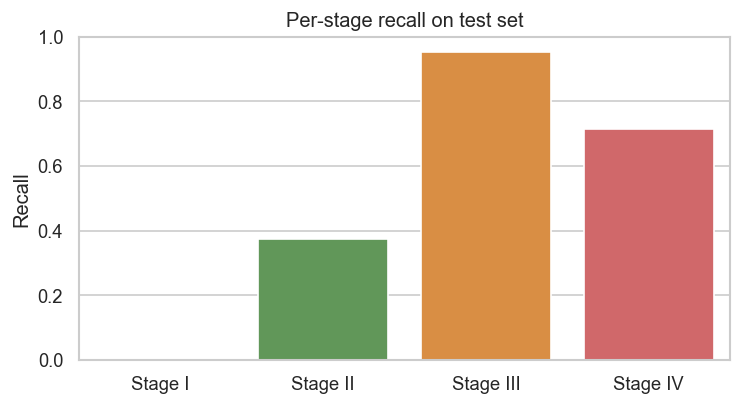

In [10]:
cm = np.array(metrics["confusion_matrix"])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
class_labels = [STAGE_NAMES[i] for i in STAGE_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title("Test confusion matrix - counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".0%", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title("Test confusion matrix - row normalized")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

recall = pd.Series(metrics["per_class_recall"]).reindex(class_labels)
plt.figure(figsize=(7, 3.5))
sns.barplot(x=recall.index, y=recall.values, hue=recall.index, palette=STAGE_PALETTE, legend=False)
plt.ylim(0, 1)
plt.title("Per-stage recall on test set")
plt.ylabel("Recall")
plt.xlabel("")
plt.show()

## Prediction Analysis

The ordinal error view is clinically useful: predicting Stage IV as Stage III is less severe than predicting Stage IV as Stage I.

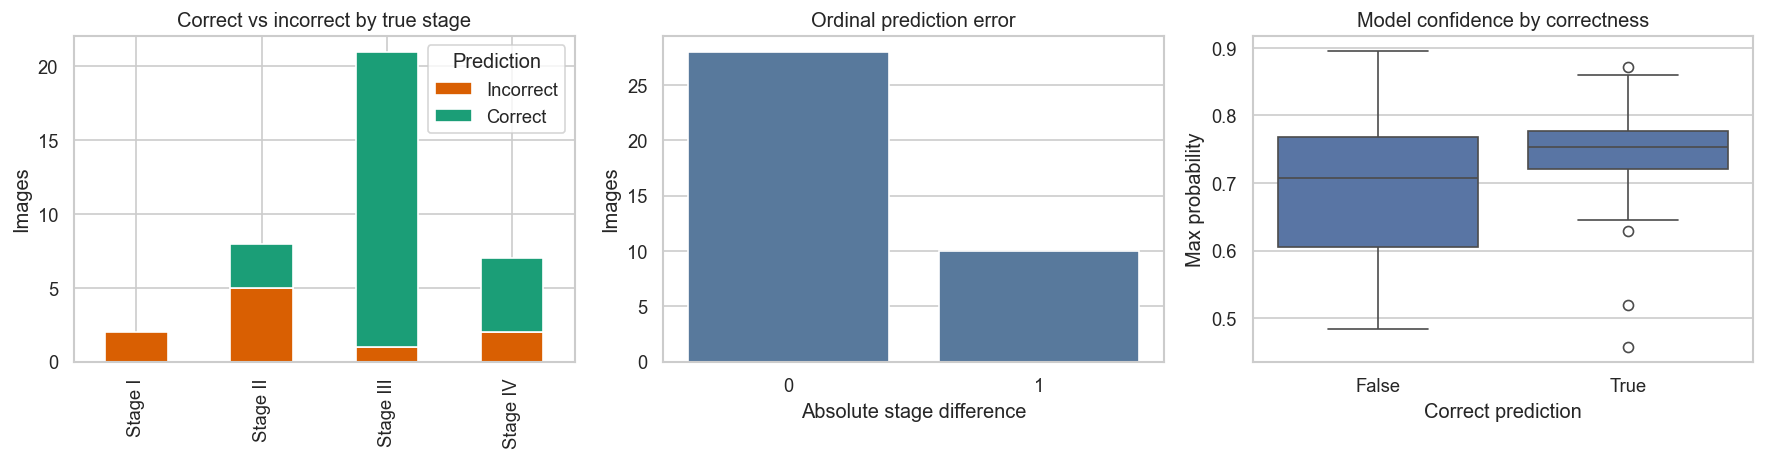

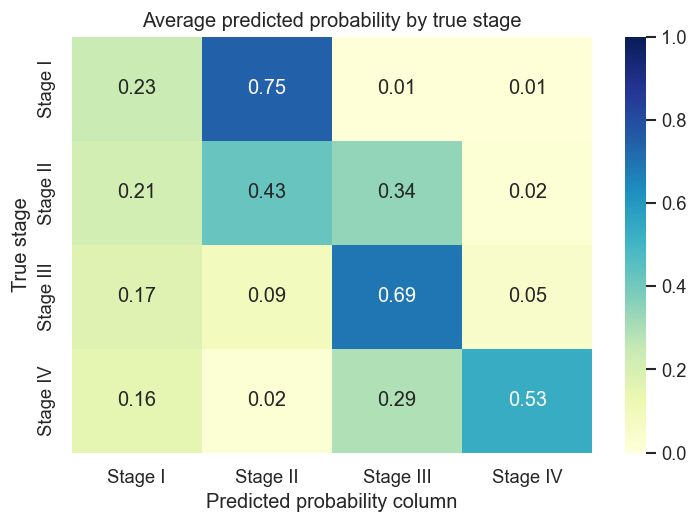

In [11]:
prob_cols = [f"prob_stage_{i}" for i in STAGE_ORDER]
preds["confidence"] = preds[prob_cols].max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

correct_counts = pd.crosstab(preds["true_stage_label"], preds["correct"]).reindex(class_labels).fillna(0)
correct_counts.plot(kind="bar", stacked=True, color=["#D95F02", "#1B9E77"], ax=axes[0])
axes[0].set_title("Correct vs incorrect by true stage")
axes[0].set_xlabel("")
axes[0].set_ylabel("Images")
axes[0].legend(["Incorrect", "Correct"], title="Prediction")

sns.countplot(data=preds, x="ordinal_error", color="#4C78A8", ax=axes[1])
axes[1].set_title("Ordinal prediction error")
axes[1].set_xlabel("Absolute stage difference")
axes[1].set_ylabel("Images")

sns.boxplot(data=preds, x="correct", y="confidence", ax=axes[2])
axes[2].set_title("Model confidence by correctness")
axes[2].set_xlabel("Correct prediction")
axes[2].set_ylabel("Max probability")

plt.tight_layout()
plt.show()

avg_probs = preds.groupby("true_stage_label")[prob_cols].mean().reindex(class_labels)
avg_probs.columns = class_labels
plt.figure(figsize=(7, 4.5))
sns.heatmap(avg_probs, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Average predicted probability by true stage")
plt.xlabel("Predicted probability column")
plt.ylabel("True stage")
plt.show()

In [12]:
mistakes = preds[~preds["correct"]].copy()
mistakes = mistakes.sort_values(["ordinal_error", "confidence"], ascending=[False, False])

display(Markdown(f"### Incorrect predictions: {len(mistakes)} / {len(preds)} test images"))
display(mistakes[[
    "image_id", "filename", "true_stage_name", "pred_stage_name",
    "ordinal_error", "confidence", "brar_age_ratio"
]].head(12).style.format({"confidence": "{:.3f}", "brar_age_ratio": "{:.3f}"}))

### Incorrect predictions: 10 / 38 test images

,image_id,filename,true_stage_name,pred_stage_name,ordinal_error,confidence,brar_age_ratio
3,131,patient_image_000131_5174739a.jpg,Stage I,Stage II,1,0.895,1.248
9,242,patient_image_000242_f0ec8ed0.jpg,Stage III,Stage II,1,0.811,1.418
18,584,patient_image_000584_388e239a.jpg,Stage IV,Stage III,1,0.774,3.135
26,802,patient_image_000802_babf562c.jpg,Stage IV,Stage III,1,0.753,1.855
1,89,patient_image_000089_cb76aaf2.jpg,Stage II,Stage III,1,0.724,1.193
2,109,patient_image_000109_d5af1e8d.jpg,Stage II,Stage III,1,0.691,1.868
13,362,patient_image_000362_37ddc399.jpg,Stage II,Stage III,1,0.635,1.256
5,147,patient_image_000147_0f29426c.jpg,Stage I,Stage II,1,0.595,1.294
0,73,patient_image_000073_f9f52225.jpg,Stage II,Stage I,1,0.503,1.111
7,184,patient_image_000184_8ce19f36.jpg,Stage II,Stage III,1,0.484,1.099


## Example Test Predictions

A small visual panel for discussing what the model got right and where it struggled.

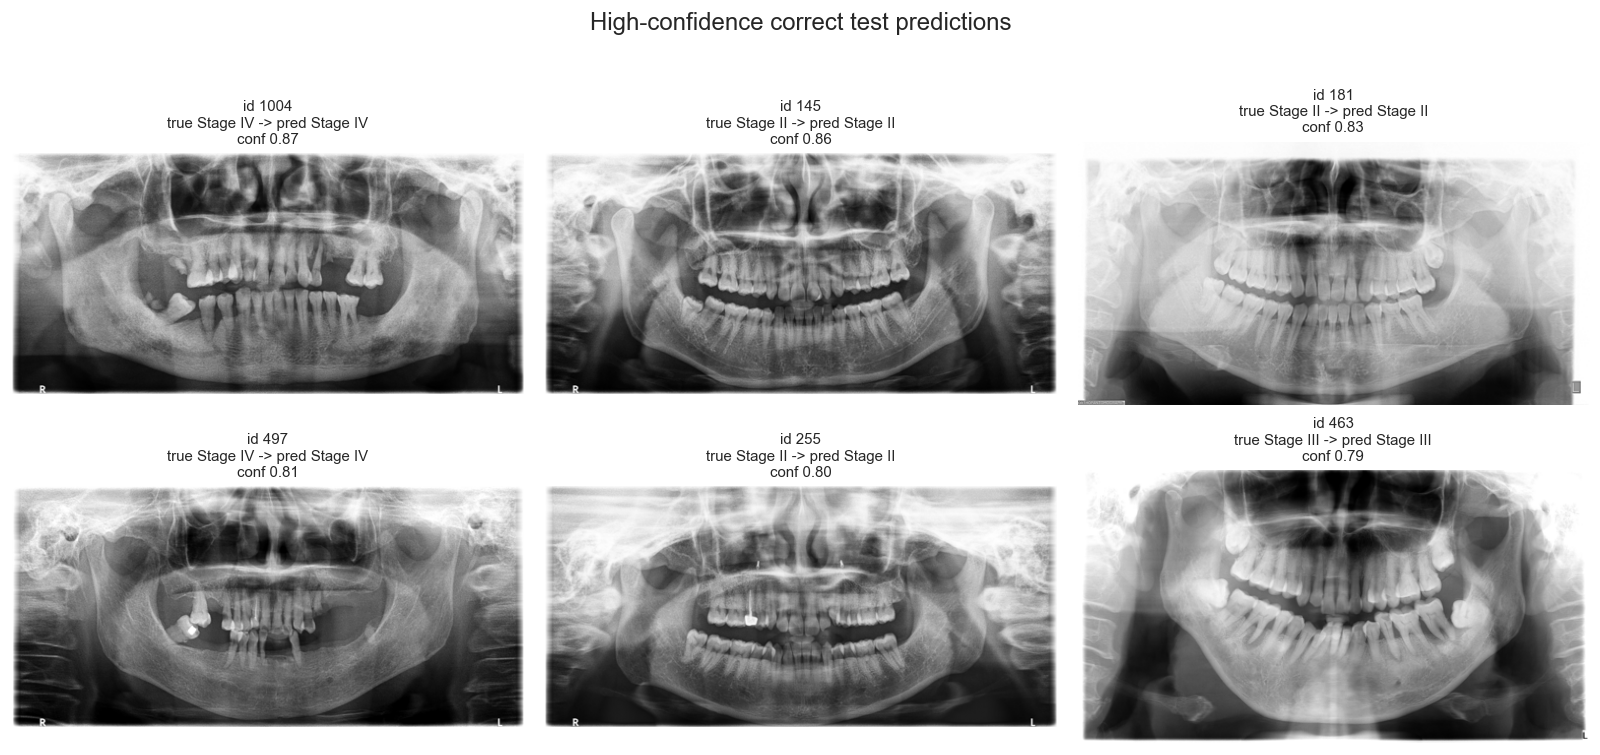

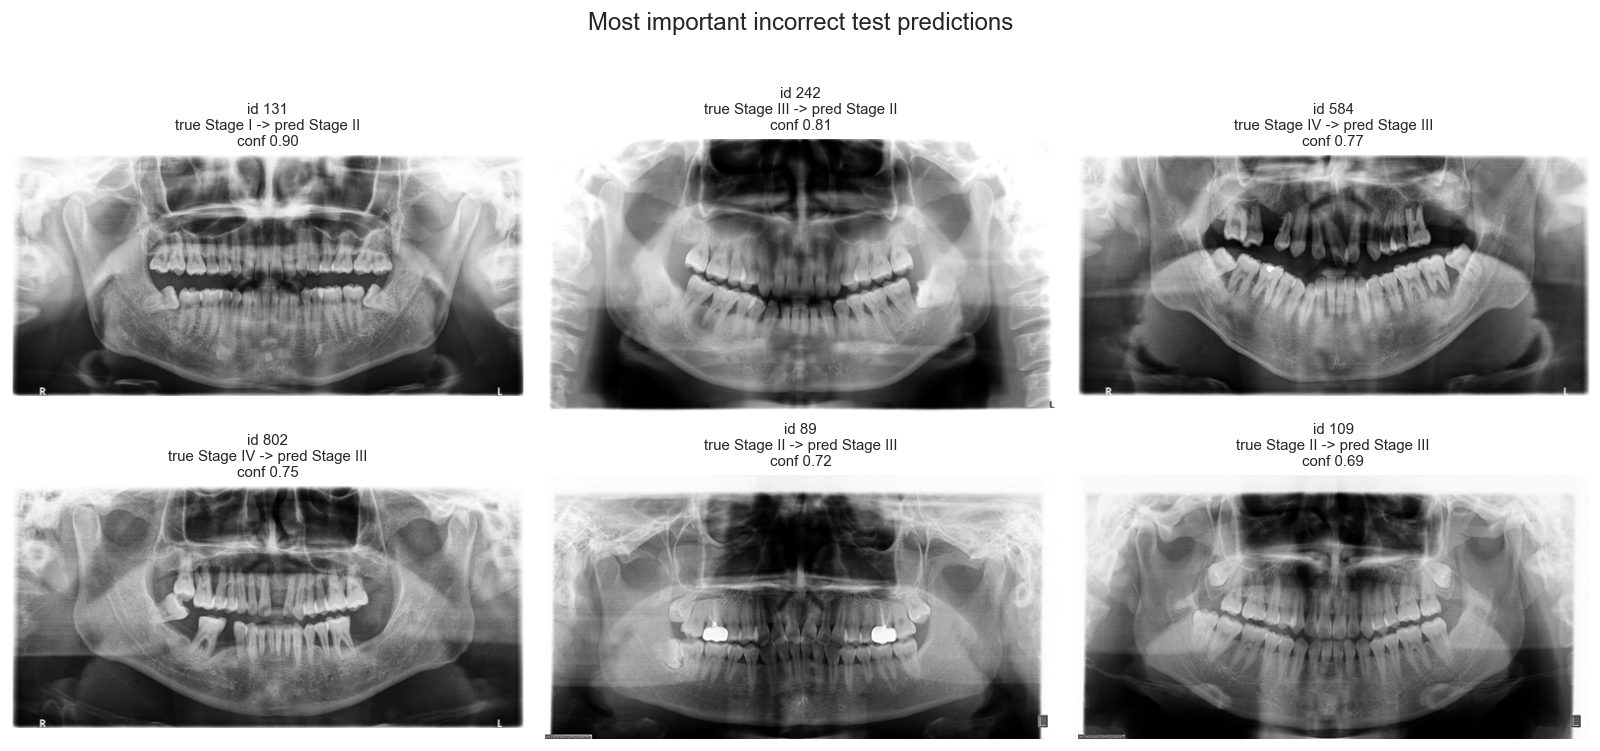

In [13]:
import pandas as pd
def show_prediction_panel(rows: pd.DataFrame, title: str, max_items: int = 6):
    rows = rows.head(max_items)
    if rows.empty:
        display(Markdown(f"No rows available for **{title}**."))
        return
    cols = min(3, len(rows))
    rows_needed = int(np.ceil(len(rows) / cols))
    fig, axes = plt.subplots(rows_needed, cols, figsize=(4.5 * cols, 3.2 * rows_needed))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, (_, row) in zip(axes, rows.iterrows()):
        img_path = DATA_ROOT / row["image_path"]
        ax.imshow(load_thumbnail(img_path), cmap="gray")
        ax.set_title(
            f"id {int(row['image_id'])}\ntrue {row['true_stage_name']} -> pred {row['pred_stage_name']}\nconf {row['confidence']:.2f}",
            fontsize=9,
        )
        ax.axis("off")
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

correct_examples = preds[preds["correct"]].sort_values("confidence", ascending=False)
wrong_examples = preds[~preds["correct"]].sort_values(["ordinal_error", "confidence"], ascending=[False, False])

show_prediction_panel(correct_examples, "High-confidence correct test predictions")
show_prediction_panel(wrong_examples, "Most important incorrect test predictions")

## Mentor Discussion Points

- The professor labels match the image files cleanly: no missing or duplicate labeled images.
- The 2017-labeled subset is small and imbalanced: Stage I has only 10 images total.
- The first image-only model learns real signal: Stage III and Stage IV performance is strong for a baseline.
- Stage I recall is currently 0 on the tiny test split, so future work should use cross-validation and possibly class-aware sampling or an ordinal objective.
- Because this is a four-stage ordered clinical problem, ordinal MAE and confusion-adjacency matter alongside accuracy.
- Best next experiment: repeated stratified splits or 5-fold cross-validation, then compare image-only, metadata ablation, smaller backbone, and ordinal-loss variants.

## Final Appendix: Three Unused BRAR Level 2 Image Tests

These three images come from the original BRAR `level_2` folder. They were **not used as professor-labeled 2017 training/evaluation samples**, so this is only a qualitative mentor check. There is no 2017 ground truth here; we are asking, visually, whether the trained model's Stage I-IV predictions look plausible.

In [14]:
import sys
import yaml
import torch
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from torchvision import transforms

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model.classifier import BRARClassifier

LEVEL_2_TEST_PATHS = [
    DATA_ROOT / "level_1" / "patient_image_000020_353539ca.jpg",
    DATA_ROOT / "level_2" / "patient_image_000880_2ca612b6.jpg",
    DATA_ROOT / "level_2" / "patient_image_000976_fedf47e3.jpg",
]

def load_checkpoint(path: Path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

def inference_transform(image_size: int):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

cfg = yaml.safe_load((PROJECT_ROOT / "config.yaml").read_text())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
stage_labels = [STAGE_NAMES[i] for i in STAGE_ORDER]

model = BRARClassifier(
    backbone=cfg["model"]["backbone"],
    pretrained=False,
    num_classes=cfg["model"]["num_classes"],
    dropout=0.0,
    use_metadata=False,
    metadata_dim=cfg["model"]["metadata_features"],
).to(device)
model.load_state_dict(load_checkpoint(RUN_DIR / "weights" / "best.pt", device))
model.eval()
tfm = inference_transform(cfg["training"]["image_size"])

level2_rows = []
with torch.no_grad():
    for path in LEVEL_2_TEST_PATHS:
        image = Image.open(path).convert("RGB")
        logits = model(tfm(image).unsqueeze(0).to(device), None)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pred_idx = int(probs.argmax())
        image_id = int(path.name.split("_")[2])
        level2_rows.append({
            "image_id": image_id,
            "path": path.as_posix(),
            "filename": path.name,
            "original_brar_folder": "level_2",
            "predicted_2017_stage": pred_idx + 1,
            "predicted_2017_stage_name": STAGE_NAMES[pred_idx + 1],
            "confidence": float(probs[pred_idx]),
            "Stage I": float(probs[0]),
            "Stage II": float(probs[1]),
            "Stage III": float(probs[2]),
            "Stage IV": float(probs[3]),
        })

level2_tests = pd.DataFrame(level2_rows)
display(Markdown(f"Model device: `{device}`. These are qualitative predictions only."))
display(level2_tests[[
    "image_id", "filename", "original_brar_folder", "predicted_2017_stage_name",
    "confidence", "Stage I", "Stage II", "Stage III", "Stage IV"
]].style.format({
    "confidence": "{:.3f}", "Stage I": "{:.3f}", "Stage II": "{:.3f}",
    "Stage III": "{:.3f}", "Stage IV": "{:.3f}"
}))

C:\Users\DT User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model device: `cuda`. These are qualitative predictions only.

,image_id,filename,original_brar_folder,predicted_2017_stage_name,confidence,Stage I,Stage II,Stage III,Stage IV
0,20,patient_image_000020_353539ca.jpg,level_2,Stage I,0.823,0.823,0.085,0.047,0.045
1,880,patient_image_000880_2ca612b6.jpg,level_2,Stage IV,0.686,0.235,0.066,0.013,0.686
2,976,patient_image_000976_fedf47e3.jpg,level_2,Stage I,0.445,0.445,0.154,0.042,0.359


In [15]:
fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[
        *(f"id {int(row['image_id'])}: {row['predicted_2017_stage_name']} ({row['confidence']:.2f})" for _, row in level2_tests.iterrows()),
        *(f"Stage probabilities - id {int(row['image_id'])}" for _, row in level2_tests.iterrows()),
    ],
    vertical_spacing=0.12,
)

for col, (_, row) in enumerate(level2_tests.iterrows(), start=1):
    image = Image.open(row["path"]).convert("RGB")
    image.thumbnail((900, 420))
    fig.add_trace(go.Image(z=np.array(image)), row=1, col=col)
    fig.add_trace(
        go.Bar(
            x=stage_labels,
            y=[row[label] for label in stage_labels],
            marker_color=[STAGE_PALETTE[label] for label in stage_labels],
            text=[f"{row[label]:.2f}" for label in stage_labels],
            textposition="outside",
            showlegend=False,
        ),
        row=2,
        col=col,
    )

fig.update_xaxes(showticklabels=False, row=1)
fig.update_yaxes(showticklabels=False, row=1)
fig.update_yaxes(range=[0, 1], title_text="Probability", row=2)
fig.update_layout(
    title="Qualitative predictions on three unused original BRAR Level 2 images",
    height=760,
    width=1200,
    margin=dict(l=20, r=20, t=95, b=20),
)
fig.show()